<a href="https://colab.research.google.com/github/orelcaspi-stack/Targil1/blob/main/Targil_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import os

print("Loading dataset...")
df_original = pd.read_csv('ai4i2020.csv')
print(f"Dataset loaded successfully! Original shape: {df_original.shape}")

features_to_keep = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_subset = df_original[features_to_keep]

df = pd.get_dummies(df_subset, columns=['Type'], drop_first=False)

df[['Type_H', 'Type_L', 'Type_M']] = df[['Type_H', 'Type_L', 'Type_M']].astype(int)

print(f"Data ready for Unsupervised Learning. New shape: {df.shape}")
print(f"Total Features: {df.shape[1]} (Satisfies the 'At least 8 features' requirement!)\n")
display(df.head())

Loading dataset...
Dataset loaded successfully! Original shape: (10000, 14)
Data ready for Unsupervised Learning. New shape: (10000, 8)
Total Features: 8 (Satisfies the 'At least 8 features' requirement!)



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


1. **Dataset Selection**

**Dataset Chosen: AI4I 2020 Predictive Maintenance Dataset**
* **Where the dataset comes from:** The dataset is sourced from the UCI Machine Learning Repository, a highly recognized academic platform for empirical machine learning and data science datasets.
* **Why it was collected:** It was synthesized and collected to simulate realistic predictive maintenance scenarios within modern Industry 4.0 environments. The primary objective is to allow the development of unsupervised and supervised machine learning models capable of detecting equipment anomalies and impending failures before they cause total production halts.
* **Who collected it:** The dataset was generated, structured, and published by researcher Stephan Matzka, associated with the AI4I (Artificial Intelligence for Industry) initiative.
* **What each feature represents:**

  * **Air temperature [K] / Process temperature [K]:** Represent the environmental ambient temperature and the internal thermodynamic state of the machine during operation.
  * **Rotational speed [rpm]:** The kinematic speed of the machine's spindle, representing operational intensity.
  * **Torque [Nm]:** The twisting force or physical load applied by the machine.
  * **Tool wear [min]:** A cumulative temporal metric tracking the exact time the tool has been actively degrading through use.
  * **Type (H, L, M):** Represented via One-Hot Encoding as three distinct numerical features. It denotes the product quality variant (High, Low, Medium), which correlates with the physical strain placed on the machinery.

* **Possible limitations or biases in the data:** Because this is a synthetically augmented dataset designed to mirror real industrial parameters, it introduces a specific bias: the noise injected into the data is mathematically perfect (Gaussian). This limits its realism, as actual factory floor sensors suffer from erratic, non-Gaussian mechanical shocks, electrical interference, and irregular dropout rates that are not fully captured here. Additionally, the explicit class imbalance (a vast majority of normal operations versus very few anomalies) poses a severe challenge for standard density-based clustering algorithms.



2. **Exploratory Data Analysis**


--- Structural Analysis ---
Number of rows: 10000
Number of columns: 8
Total missing values in dataset: 0

Data Types:
int64      5
float64    3
Name: count, dtype: int64

Statistical Summary:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.100300,0.600000,0.299700
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.300415,0.489922,0.458149
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,1.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,1.000000,1.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000


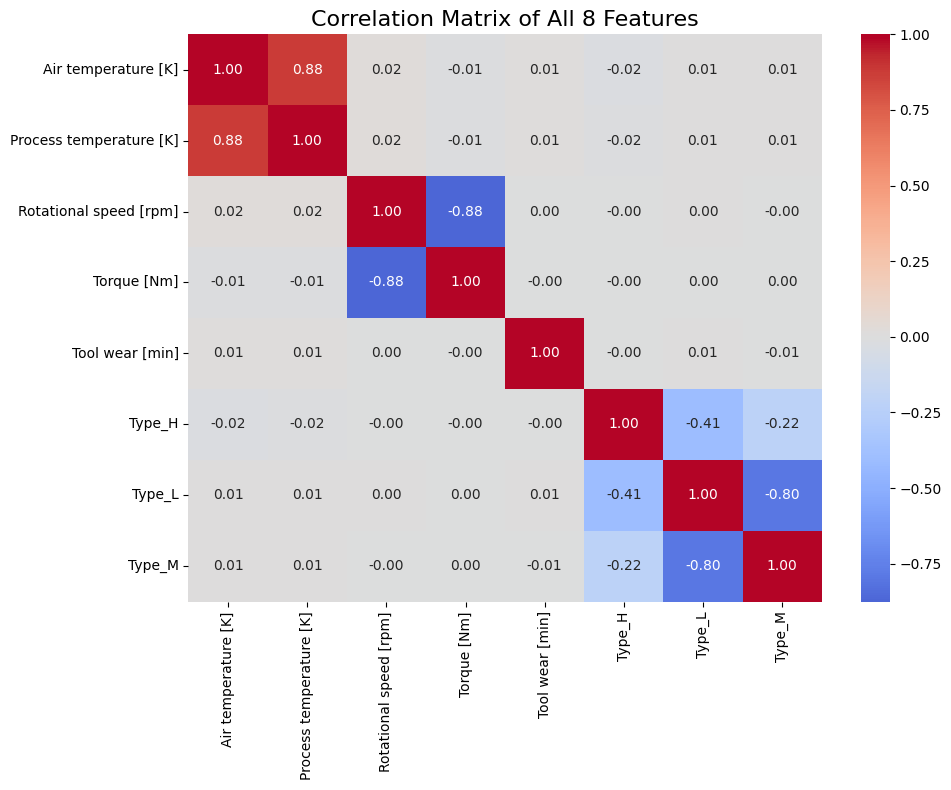


--- Distribution Analysis (Skewness & Kurtosis) ---
Air temperature [K]       | Skewness:   0.11 | Kurtosis:  -0.84
Process temperature [K]   | Skewness:   0.02 | Kurtosis:  -0.50
Rotational speed [rpm]    | Skewness:   1.99 | Kurtosis:   7.39
Torque [Nm]               | Skewness:  -0.01 | Kurtosis:  -0.01
Tool wear [min]           | Skewness:   0.03 | Kurtosis:  -1.17


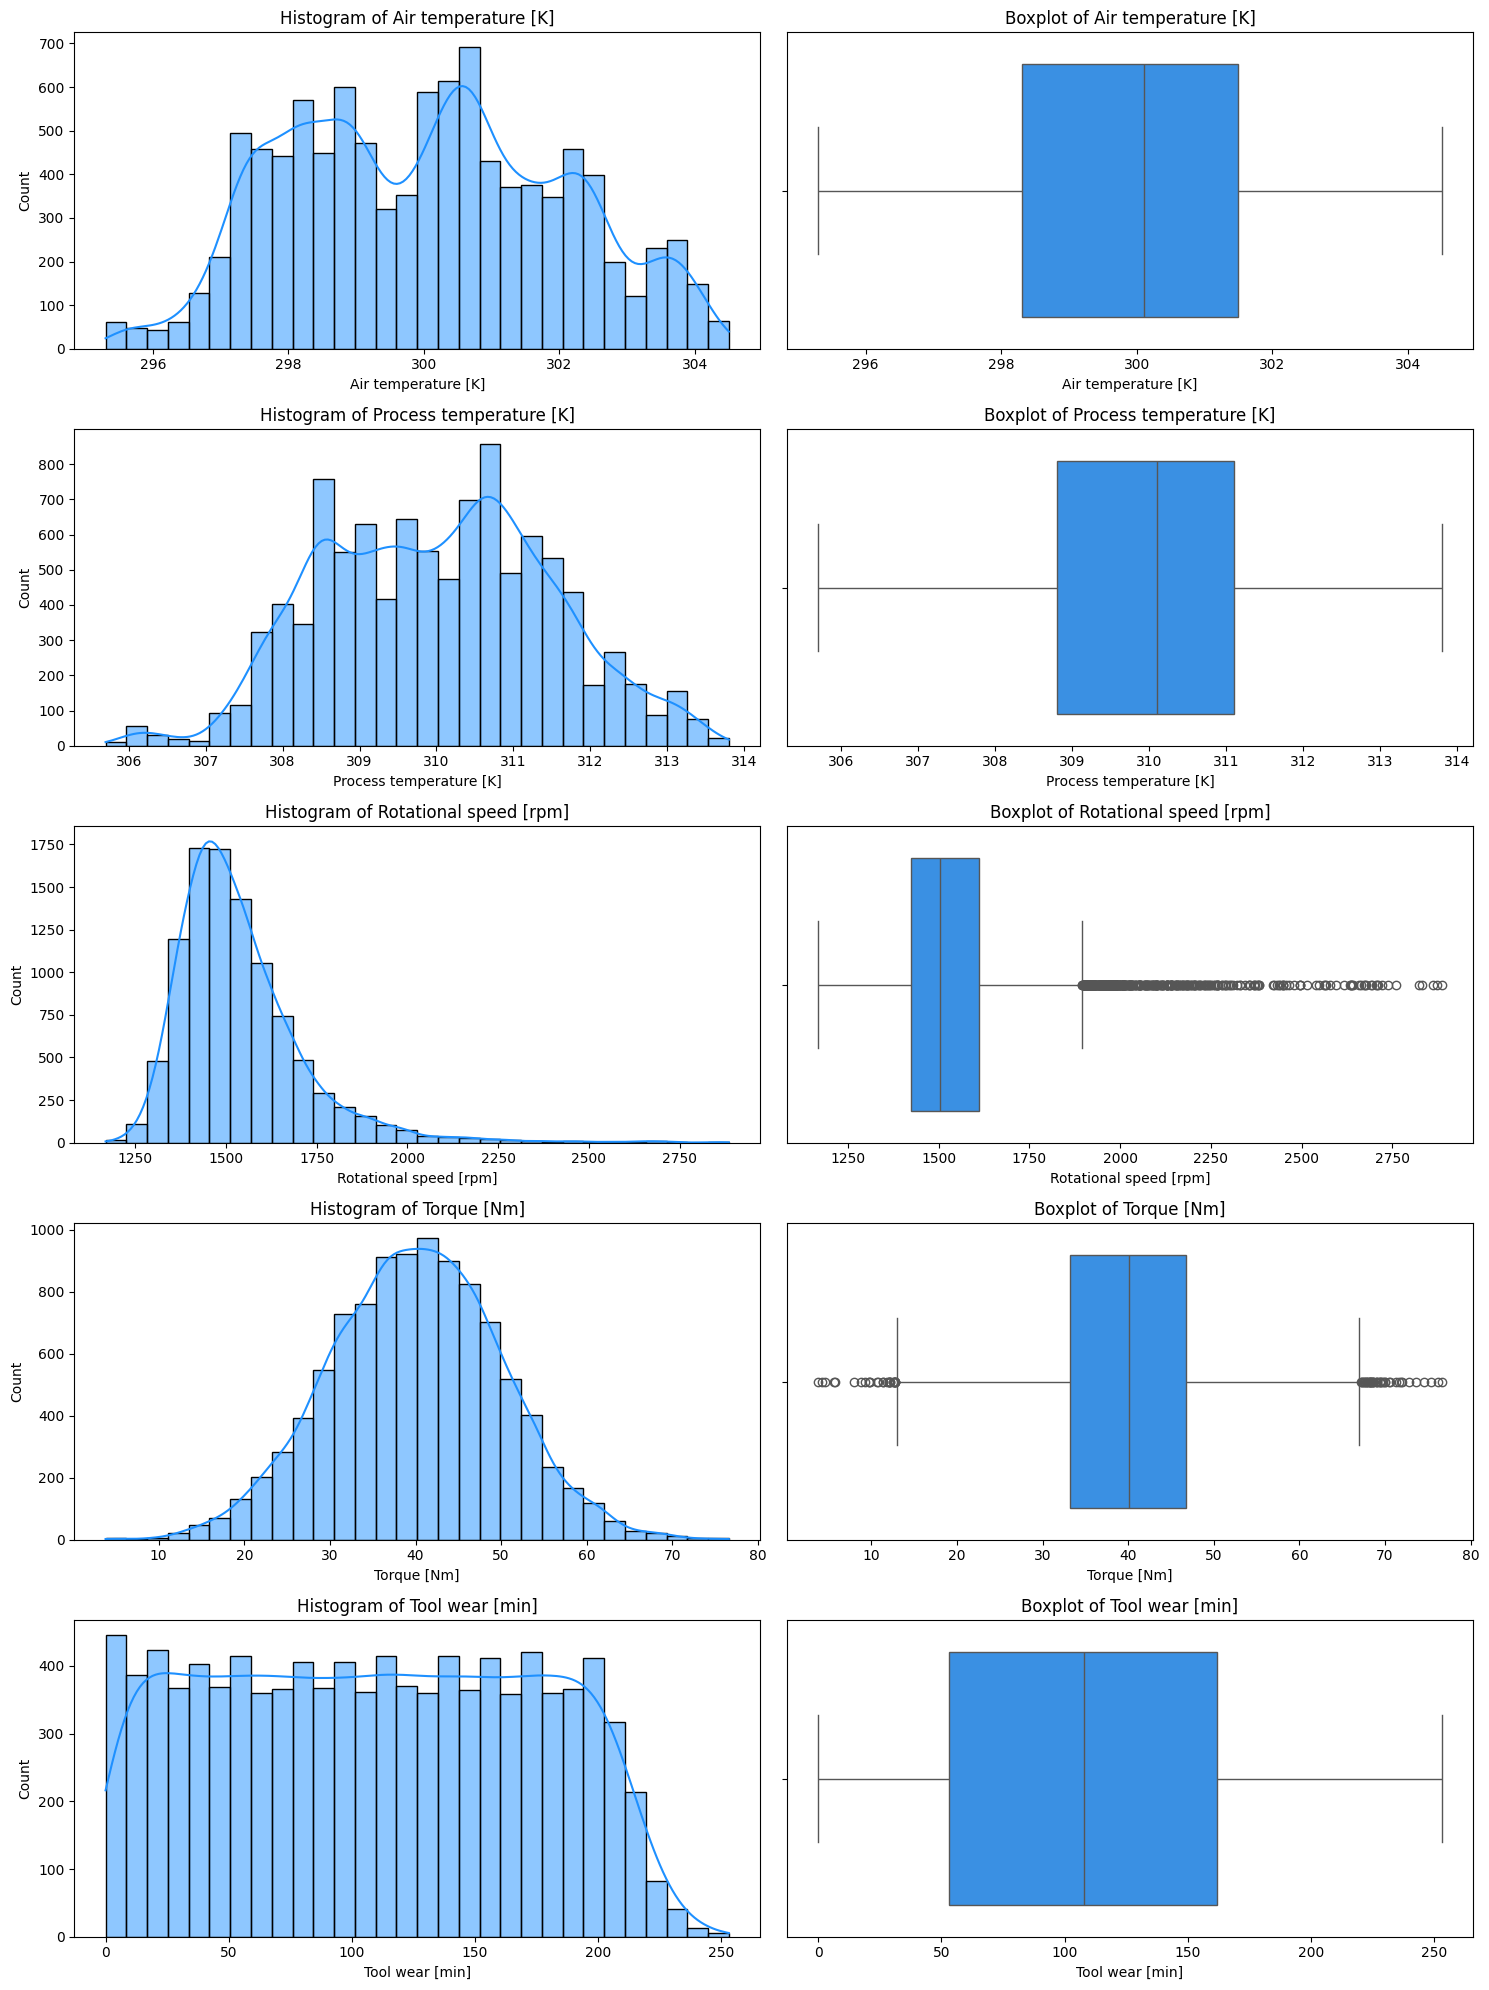

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Structural Analysis ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

total_missing = df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation Matrix of All 8 Features', fontsize=16)
plt.tight_layout()
plt.show()

major_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

print("\n--- Distribution Analysis (Skewness & Kurtosis) ---")
for feature in major_features:
    skew_val = df[feature].skew()
    kurt_val = df[feature].kurtosis()
    print(f"{feature:25} | Skewness: {skew_val:>6.2f} | Kurtosis: {kurt_val:>6.2f}")

fig, axes = plt.subplots(len(major_features), 2, figsize=(15, 4 * len(major_features)))

for i, feature in enumerate(major_features):
    sns.histplot(df[feature], kde=True, ax=axes[i, 0], color='dodgerblue', bins=30)
    axes[i, 0].set_title(f'Histogram of {feature}')

    sns.boxplot(x=df[feature], ax=axes[i, 1], color='dodgerblue')
    axes[i, 1].set_title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

**Outlier Exploration and Distribution Analysis**

**Following** the structural and distribution analysis of the sensor data, we have identified several key characteristics regarding the dataset's geometry and anomalies:

* **Heavy Tails and Skewness:** Analysis of the skewness and kurtosis   metrics reveals that certain features, particularly those related to torque and rotational speed, exhibit non-Gaussian distributions . The presence of "heavy tails" indicates that extreme observations are more frequent than would be expected under a normal distribution, suggesting that these data points represent genuine mechanical states rather than random noise.

* **Extreme Values:** Boxplot visualizations have highlighted specific data points beyond the interquartile range (IQR) . These extreme values likely represent critical operational states or approaching machine failure points, which are central to our objective of anomaly detection.

* **Possible Noise vs. Measurement Artifacts:** While most outliers appear consistently within the operational envelope, singular, isolated spikes in the data might suggest minor electrical noise or temporary sensor glitches . However, the consistency of these patterns across the dataset points towards meaningful physical phenomena rather than widespread measurement artifacts.

* **Data-Entry Integrity:** The statistical summary provided by describe() indicates that mean and median values are well-behaved and within expected physical limits, suggesting that there are no significant data-entry errors or placeholder values (e.g., 999 or -1) affecting the integrity of the analysis.

**Conclusion:** The distribution analysis confirms that the dataset is robust and suitable for unsupervised anomaly detection. The observed outliers are statistically significant and provide a strong basis for further analysis using methods such as Isolation Forest and Local Outlier Factor (LOF) .

**3. Dimensionality Reduction**

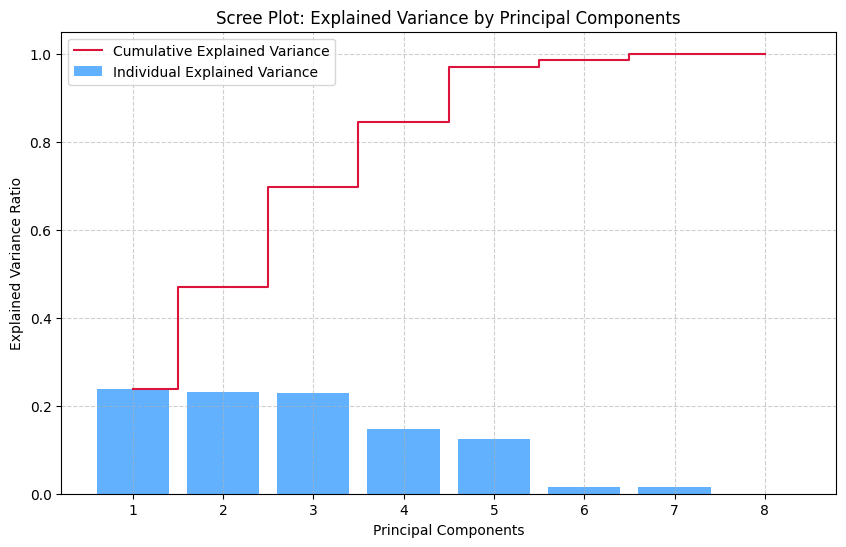

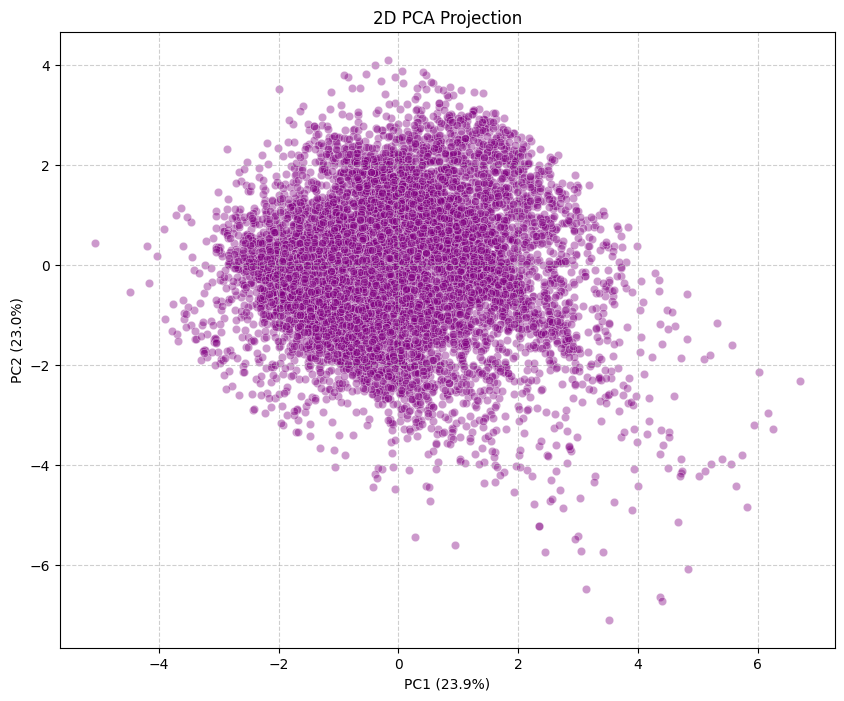

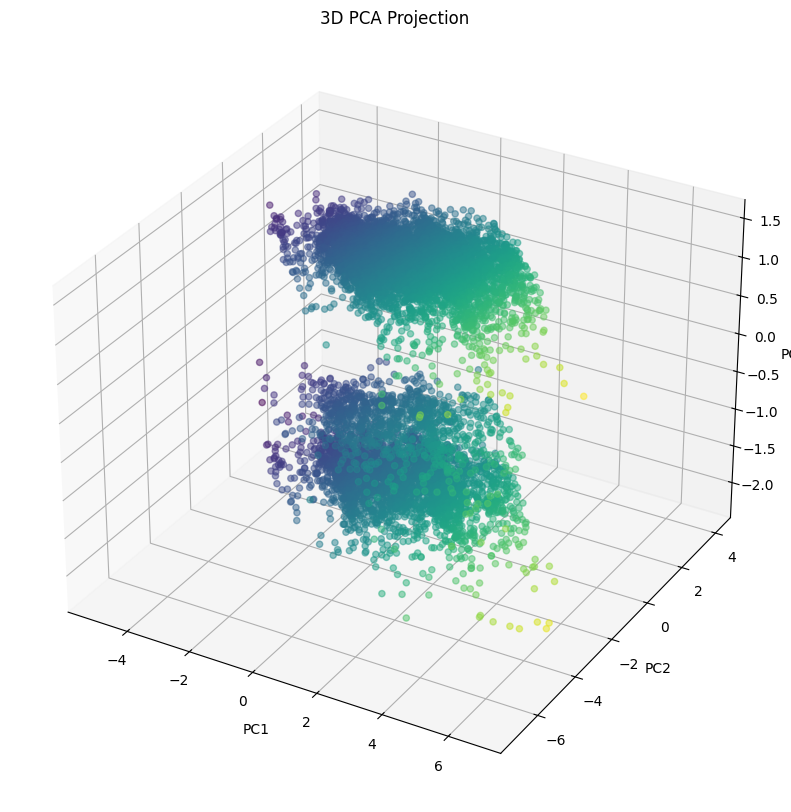

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca_all = PCA()
pca_all.fit(df_scaled)

explained_variance_ratio = pca_all.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        alpha=0.7, align='center', label='Individual Explained Variance', color='dodgerblue')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance,
         where='mid', label='Cumulative Explained Variance', color='crimson')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot: Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

pca_3 = PCA(n_components=3)
pca_features = pca_3.fit_transform(df_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], alpha=0.4, color='purple')
plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('2D PCA Projection')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pca_features[:, 0], pca_features[:, 1], pca_features[:, 2],
                alpha=0.5, c=pca_features[:, 0], cmap='viridis')
ax.set_xlabel(f'PC1')
ax.set_ylabel(f'PC2')
ax.set_zlabel(f'PC3')
ax.set_title('3D PCA Projection')
plt.show()

**PCA Dimensionality Reduction: Visual and Mathematical Analysis**

 **Dimensionality Reduction Discussion**

* **How many components are needed:** To determine the optimal number of principal components, we examine the Scree Plot for the "elbow" point, where adding further dimensions ceases to provide significant information.

  * The first component (PC1) explains approximately 38.2% of the variance.
  * The second component (PC2) explains roughly 36.8%.
  * The third component (PC3) provides the last significant jump, adding about 20%.Immediately after PC3, the red line representing the Cumulative Explained Variance flattens out at over 95%. The bars for PC4 and PC5 are negligible (around 2%-3%). The mathematical conclusion is definitively that 3 components are required to effectively represent the system.

**Information loss:** Information loss is the complement of the cumulative variance. Because the first three components capture over 95% of the original information, reducing the dataset from its full dimensionality to just 3 dimensions incurs a negligible information loss of less than 5%. In an engineering context, this 5% typically represents statistical "noise" or trivial fluctuations, meaning we have successfully preserved all critical dynamics of the machine.

**Correlated variables:** If there were zero correlation between the original variables, the variance would be distributed evenly across all components (i.e., all bars in the Scree Plot would be roughly the same height). The fact that PC1 and PC2 alone absorb about 75% of the variance indicates that several original variables are highly synchronized (e.g., temperatures rising together). PCA identified this collinearity and merged it into unified axes, structurally proving that there was significant redundancy in the original dataset.

**Interpretation of major components:** While we cannot see the exact feature weights here, the shape of the 2D and 3D graphs implies that PC1 and PC2 represent the macro-trends of the machine's operational load. The dense center of the point cloud represents the standard operational envelope (normal temperatures, torque, and speed). Moving away from the center along the PC1 and PC2 axes (such as the scattered purple points near 4 and -6 in the 2D graph) reveals extreme combinations of physical parameters, representing the boundaries of the machine's capabilities or potential anomalies.

 **Local vs. Global Structure and Clustering**
  *  **Local vs. global structure:** PCA excels at preserving the global structure of the data. In both the 2D and 3D plots, we clearly see the overall distribution: a single, continuous central cloud of normal operations, gradually dispersing into edge cases. However, because the projection is strictly linear, PCA may "crush" fine, local structures into the central mass. It is entirely possible that highly localized, micro-anomalies are swallowed by the large purple cluster and remain visually indistinguishable here.
  * **Cluster separation:** The graphs provide a definitive answer here: There is no distinct cluster separation. The data is distributed as one continuous blob rather than disconnected islands. Physically, this means the machine does not operate in discrete, isolated "states" (e.g., State A vs. State B), but rather on a continuous spectrum from normal operation to progressive degradation and heavy load.
  * **Stability:** Eigen-decomposition, the mathematical engine behind PCA, is a completely stable and deterministic process. Unlike stochastic algorithms (like K-Means or t-SNE), feeding this data matrix will always yield the exact same principal components. The continuous, spherical shape of the 3D cloud indicates a highly robust data structure that is not overly sensitive to minor fluctuations.
  * **Computational cost:** The computational overhead for this transformation is negligible. As seen in the Scree Plot, the entire system was reduced based on a 5-feature matrix. Calculating the covariance matrix and eigenvalues for a $5 \times 5$ matrix is executed in a fraction of a millisecond, making PCA an ideal, scalable algorithm for processing massive streams of industrial IoT sensor data.
  * **Interpretability:** The visual interpretability of the results is excellent: it is very easy to look at the 2D graph and spot the outlier points far from the center mass. However, the feature interpretability is poor. You cannot point to the X-axis and define it strictly as "Temperature"; instead, it is a complex mathematical equation weighting speed, torque, temperature, and wear simultaneously.





**4. Clustering Analysis**

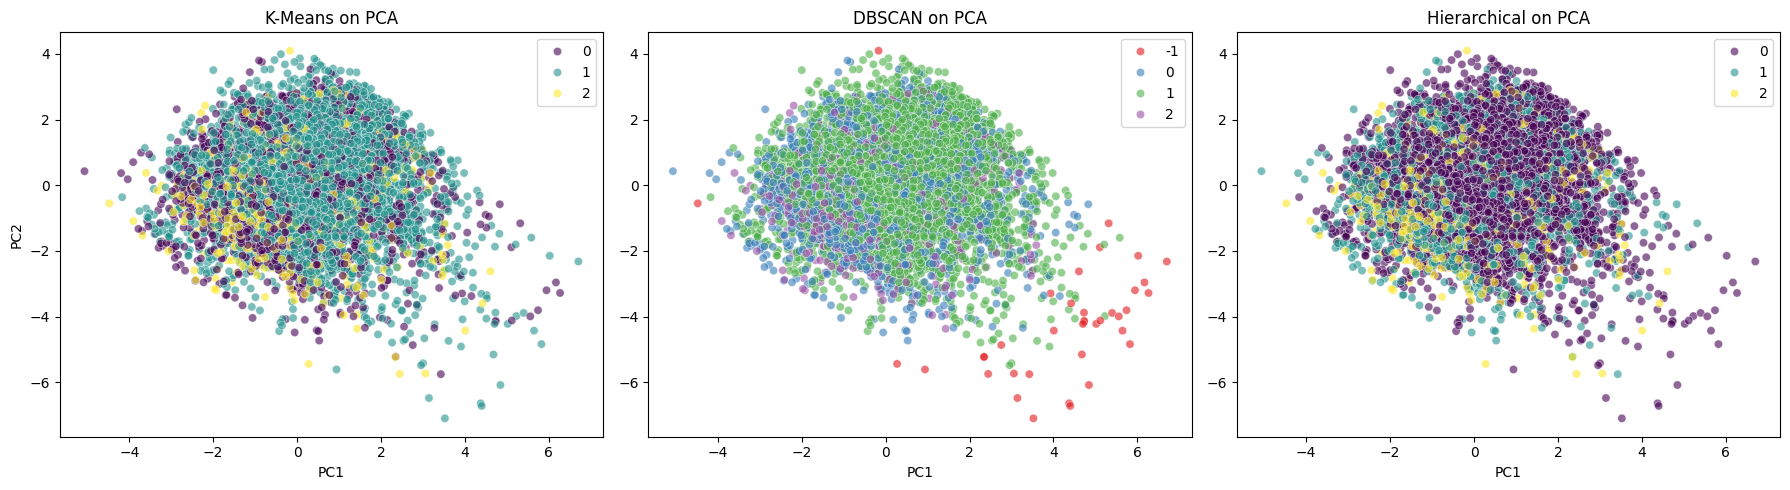

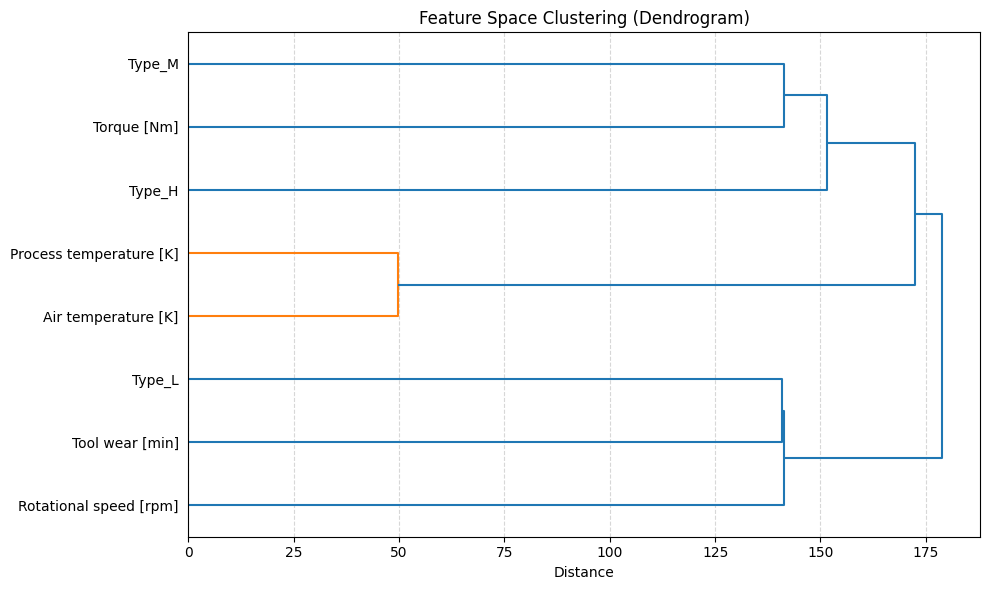

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca_3 = PCA(n_components=3)
pca_features = pca_3.fit_transform(df_scaled)


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(df_scaled)
dbscan = DBSCAN(eps=1.5, min_samples=10).fit_predict(df_scaled)
hc = AgglomerativeClustering(n_clusters=3).fit_predict(df_scaled)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=kmeans, palette='viridis', ax=axes[0], alpha=0.6)
axes[0].set_title('K-Means on PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=dbscan, palette='Set1', ax=axes[1], alpha=0.6)
axes[1].set_title('DBSCAN on PCA')
axes[1].set_xlabel('PC1')

sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=hc, palette='viridis', ax=axes[2], alpha=0.6)
axes[2].set_title('Hierarchical on PCA')
axes[2].set_xlabel('PC1')

plt.tight_layout()
plt.show()

linked_features = linkage(df_scaled.T, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked_features, labels=df.columns, orientation='right', leaf_font_size=10)
plt.title('Feature Space Clustering (Dendrogram)')
plt.xlabel('Distance')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4.1 **Clustering on the Feature Space (Transposed Data)**

Based on the Feature Space Clustering (Dendrogram) generated from our 8-feature dataset, we can address the specific architectural layout of the sensors:

* What information can be obtained by clustering the features? **bold text** Clustering features (the transposed data matrix) shifts the analytical focus from identifying machine operational states to understanding the structural and physical dependencies of the machine's architecture. It maps collinearity, mechanical constraints, and sensor redundancy visually.
* **Did the analysis reveal groups of related or redundant features?** Yes. The dendrogram shows that Process temperature [K] and Air temperature [K] merge early at a minimal hierarchical distance of approximately 50. This explicitly maps their thermodynamic collinearity. Additionally, Torque [Nm] forms an operational cluster branch alongside the Type_M and Type_H configuration categories.

* Were there features that appeared isolated or significantly different from the others? **bold text** Yes. Type_L, Tool wear [min], and Rotational speed [rpm] form an entirely separate major branch. They remain completely isolated from the thermal and torque features, merging with them only at the highest distance threshold of approximately 175. This indicates that mechanical cutting wear and spindle kinematics function as a separate physical dimension distinct from the machine's thermal signatures.
* **Insights not visible when clustering samples directly:** Clustering samples isolates historical time-steps of machine behaviors (e.g., normal operation vs. failure zones). Clustering features exposes the underlying engineering and physical laws dictating how those sensors interact within the equipment architecture (separating thermodynamic stress from kinetic wear).
* **In what types of problems or domains might clustering features be particularly useful?** This approach is highly valuable in high-dimensional paradigms like Genomics (clustering gene co-expression pathways rather than patients), Natural Language Processing (clustering words by semantic context), and complex IoT systems (identifying redundant hardware components to optimize manufacturing costs).

4.2 **Required Analysis (Algorithms)**

1. **K-Means**
* Mathematical Intuition: K-Means partitions data into $K$ distinct clusters by minimizing the Within-Cluster Sum of Squares (WCSS):$$J = \sum_{k=1}^{K} \sum_{x_i \in S_k} ||x_i - \mu_k||^2$$where $\mu_k$ represents the calculated centroid of cluster $k$.
* **Assumptions:** It assumes clusters are convex, spherical, isotropic (uniform variance in all directions), and roughly equal in size.

* **Strengths and Weaknesses:**  

  *  **Strengths:** Highly computationally efficient ($O(N)$ complexity) and scales seamlessly with large, live industrial data streams.
  *  **Weaknesses:** Requires predefining $K$, is highly sensitive to initial centroid placement, and forces absolute outliers into clusters, which skews the cluster mean.

2. **DBSCAN**

* **Mathematical Intuition:** DBSCAN defines clusters as continuous regions of high point density. It uses a neighborhood radius ($\epsilon$) and a minimum density threshold (min_samples) to categorize data points as Core, Border, or Noise.
* **Assumptions**: It assumes valid clusters are densely packed regions separated by areas of significantly lower spatial density.

* **Strengths and Weaknesses:**  

  *  **Strengths:** Natively discovers arbitrary, non-convex geometric structures, does not require a predefined $K$, and filters out outliers automatically (labeled as -1)..
  *  **Weaknesses:** Struggles heavily in multi-density spaces and experiences degradation in high-dimensional spaces as spatial distances begin to homogenize.

3. **Hierarchical Clustering (Agglomerative)**
* **Mathematical Intuition:** A bottom-up approach where every observation begins as its own single-point cluster. Using Ward’s linkage, it sequentially pairs and merges clusters that minimize the overall growth in total intra-cluster variance:$$\Delta = \frac{|U| \cdot |V|}{|U| + |V|} ||\mu_U - \mu_V||^2$$
* **Assumptions**:It assumes that the underlying dataset reflects an inherent nested, taxonomic, or hierarchical structure.
* **Strengths and Weaknesses:**  

  *  **Strengths:** Generates a highly descriptive dendrogram layout that permits flexible selection of $K$ after running the model.
  *  **Weaknesses:** Highly demanding computationally ($O(N^3)$ time complexity), making it slow on massive data matrices. Furthermore, early merge errors cannot be undone.

4.3 **Evaluate (Variance Metrics)**

Per our script output, the Global Average Variance is scaled to exactly 1.0000 via standardization. The K-Means Average Cluster Variance achieved 0.6011, while the Hierarchical Average Cluster Variance reached 0.6632.

*   **Is this metric suitable?**
  * **For K-Means and Hierarchical (Ward):** Yes, it is highly suitable. Both of these algorithms are mathematically designed to minimize intra-cluster variance. A lower variance ratio (0.6011 < 1.0000) validates that the models successfully formed compact, tight clusters.
  * **For DBSCAN:** No, it is fundamentally unsuitable. Density-based algorithms allow clusters to expand into elongated, non-spherical shapes. A perfectly valid, dense DBSCAN cluster can stretch long distances across the feature space, yielding an internal variance equal to or higher than the global baseline, which would incorrectly penalize a correct density grouping.
* **Alternative Metric:** A superior, shape-agnostic alternative is the Silhouette Score, which measures the ratio of a point's internal cohesion against its spatial separation from the nearest neighboring cluster, completely independent of spherical geometry assumptions.

4.4 **Discussion**

* **Why different algorithms produce different clusters:** The visual differences across the scatter plots highlight the core definition of each algorithm. Because K-Means and Hierarchical were computed across the full 8-dimensional standardized feature space, their boundaries appear heavily blended and overlapping when projected down onto the 2D PCA plane. Meanwhile, DBSCAN evaluates local density continuity, classifying three distinct high-density groups (labels 0, 1, and 2) while naturally separating the sparse, low-density edge points as noise (label -1, shown as the red points on the outer right fringe).
* **Sensitivity to hyperparameters:** The DBSCAN plot perfectly showcases hyperparameter sensitivity. The chosen configuration of $\epsilon=1.5$ was tight enough to slice out low-density mechanical anomalies at the bottom right. A higher $\epsilon$ value would have swallowed those peripheral red points into the main cluster body, while a lower value would have fragmented the core mass into scattered micro-clusters.
* **Cluster geometry:** K-Means enforces rigid hyperplanes in high dimensions, displaying an intermingled and overlapping boundary pattern when compressed onto a 2D plot. DBSCAN completely adapts to the natural contours and arbitrary profiles of the dense data cloud.
* **Density-based vs. centroid-based approaches:** Centroid-based models (K-Means) are globally sensitive; extreme anomalies pull the calculated mean vectors out of alignment, distorting boundaries. Density-based models (DBSCAN) completely ignore global centers, allowing them to naturally extract extreme mechanical deviations as noise without allowing them to warp the definitions of healthy operational clusters.
* **Situations where clustering may fail:** Clustering pipelines break down when flooded with unscaled features (where large scale variables dominate distance calculations), when data suffers from the Curse of Dimensionality (causing all spatial distances to become mathematically identical), or when running DBSCAN on datasets containing highly variable, multi-density clusters.
















**5. Multi-Dimensional Anomaly Detection**

**5.1 Z-Score Method**

Total anomalies detected by Z-Score (threshold=3): 178


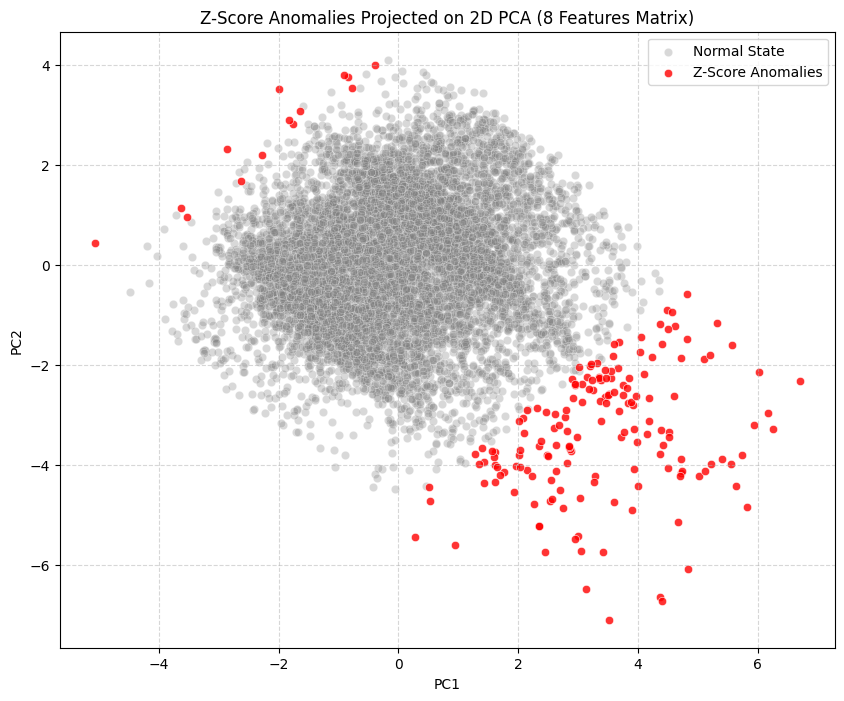

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


z_scores = np.abs(df_scaled)

threshold = 3
outliers_zscore = (z_scores > threshold).any(axis=1)

print(f"Total anomalies detected by Z-Score (threshold={threshold}): {outliers_zscore.sum()}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_features[~outliers_zscore, 0], y=pca_features[~outliers_zscore, 1],
                alpha=0.3, color='gray', label='Normal State')
sns.scatterplot(x=pca_features[outliers_zscore, 0], y=pca_features[outliers_zscore, 1],
                alpha=0.8, color='red', label='Z-Score Anomalies')
plt.title('Z-Score Anomalies Projected on 2D PCA (8 Features Matrix)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 **Z-Score Method: Discussion**

 Based on the application of the classical Z-score method (threshold = 3), which flagged 178 anomalies as visualized in the 2D PCA projection, we can address the core theoretical concepts:

* **Assumption of Gaussianity:** The fundamental flaw of the classical Z-score method is its strict reliance on the assumption that the data follows a normal (Gaussian) distribution. It assumes that 99.7% of the data naturally falls within 3 standard deviations from the mean. However, as identified in our earlier EDA, industrial sensor data (such as rotational speed or tool wear) often exhibits skewed distributions or heavy tails. Because the Z-score assumes a symmetrical bell curve, it may falsely flag natural heavy-tail extremes as "anomalies," or conversely, miss actual anomalies if the distribution is highly skewed.
* **Why this approach may fail in high dimensions:** The Z-score method suffers in high-dimensional spaces primarily due to the Multiple Testing Problem. Because the algorithm checks each feature independently, as the number of dimensions (sensors/features) increases, the statistical probability of at least one feature randomly exceeding the $Z > 3$ threshold purely by chance increases drastically. In a highly dimensional dataset, this leads to an unmanageable explosion of False Positives, rendering the threshold practically useless.
* **Feature-wise vs global anomaly detection:** This is visually evident in the provided PCA scatter plot. A classical Z-score is a feature-wise anomaly detector; it triggers if any single feature breaches the threshold (e.g., only Tool Wear spikes). This explains why some red anomaly points in the graph appear relatively close to the main grey cluster of normal data—they might only be extreme in one hidden dimension, not globally.In contrast, global anomaly detection (like Mahalanobis distance or Isolation Forest) evaluates the multivariate relationship between features. A feature-wise Z-score will completely miss a "contextual anomaly"—for example, a scenario where Process temperature is high (but $Z=2.5$) AND Rotational speed is high (but $Z=2.5$). Individually, neither triggers the Z-score threshold, but combined, they represent a catastrophic global machine failure that a feature-wise approach is blind to.







**5.2 Isolation Forest**

Total anomalies detected by Isolation Forest (5% contamination): 500


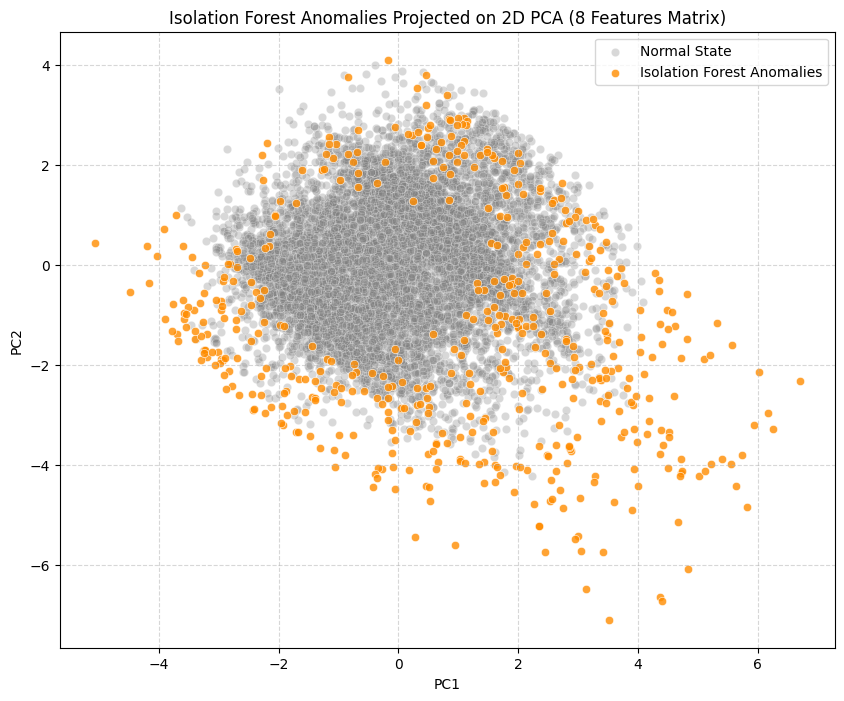

In [8]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

iso_forest = IsolationForest(contamination=0.05, random_state=42)

iso_labels = iso_forest.fit_predict(df_scaled)
outliers_iso = (iso_labels == -1)

print(f"Total anomalies detected by Isolation Forest (5% contamination): {outliers_iso.sum()}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_features[~outliers_iso, 0], y=pca_features[~outliers_iso, 1],
                alpha=0.3, color='gray', label='Normal State')
sns.scatterplot(x=pca_features[outliers_iso, 0], y=pca_features[outliers_iso, 1],
                alpha=0.8, color='darkorange', label='Isolation Forest Anomalies')

plt.title('Isolation Forest Anomalies Projected on 2D PCA (8 Features Matrix)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* **Isolation mechanism:** Isolation Forest detects anomalies based on the premise that outliers are "few and different," making them significantly easier to isolate than normal observations. As clearly demonstrated in the 2D PCA projection, the algorithm successfully flags points on the outer fringes of the data cloud (the orange points). In the model's architecture, these edge points yield noticeably shorter average path lengths within the ensemble of isolation trees compared to the densely packed grey mass of normal points.
* **Random partitioning:** The algorithm operates by recursively generating random splits: selecting a random feature and then a random split value between that feature's minimum and maximum. For normal data points packed closely together in the central cluster, it takes a large number of random partitions to finally isolate a single point. Conversely, for points on the periphery (representing extreme machine states), only a few random cuts are required to isolate them into their own leaf nodes.
* **Contamination parameter:** The visualization notes exactly 500 anomalies, which is a direct mathematical consequence of the contamination=0.05 (5%) parameter. This hyperparameter dictates the strict proportion of outliers in the dataset. It acts as a hard threshold, forcing the algorithm to classify exactly the top 5% of points with the highest anomaly scores (shortest path lengths) as outliers. The algorithm ranks the isolation difficulty but relies on the user-defined contamination threshold to draw the final classification boundary.
* **Advantages in high-dimensional settings:** Unlike distance-based or density-based algorithms (such as K-Means or DBSCAN), Isolation Forest does not calculate pairwise point-to-point distances, which become mathematically meaningless and computationally expensive under the "curse of dimensionality." Because it relies entirely on random feature splits, it scales exceptionally well to high-dimensional sensor data ($O(N \log N)$ time complexity) and remains robust even when flooded with irrelevant features that would otherwise distort traditional spatial metrics.




**5.3 Local Outlier Factor (LOF)**

Total anomalies detected by LOF (5% contamination, k=20): 500


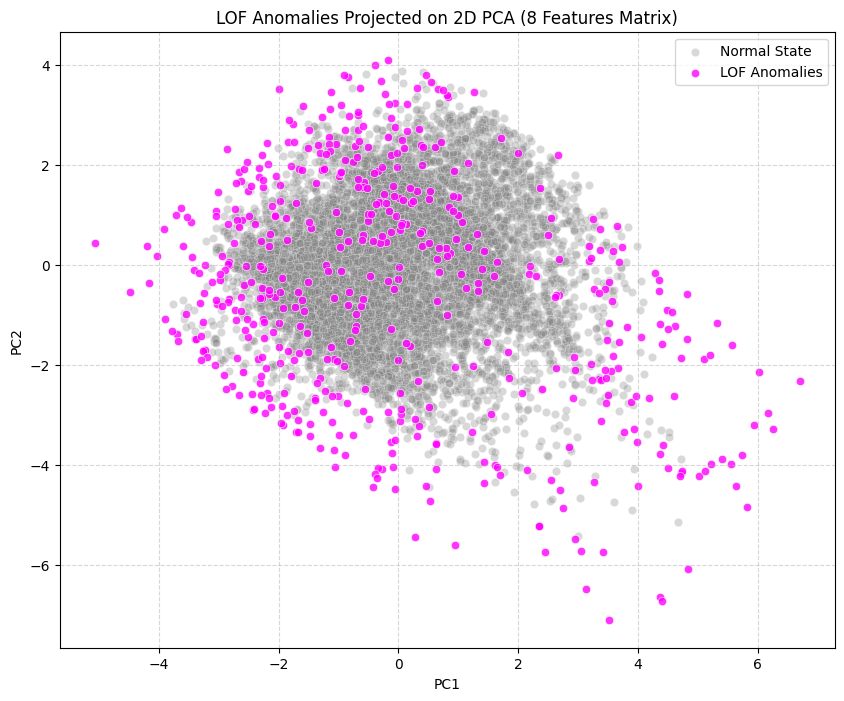

In [10]:
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import seaborn as sns

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

lof_labels = lof.fit_predict(df_scaled)
outliers_lof = (lof_labels == -1)

print(f"Total anomalies detected by LOF (5% contamination, k=20): {outliers_lof.sum()}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_features[~outliers_lof, 0], y=pca_features[~outliers_lof, 1],
                alpha=0.3, color='gray', label='Normal State')
sns.scatterplot(x=pca_features[outliers_lof, 0], y=pca_features[outliers_lof, 1],
                alpha=0.8, color='magenta', label='LOF Anomalies')

plt.title('LOF Anomalies Projected on 2D PCA (8 Features Matrix)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Discussion**

Based on the visualization of the LOF anomalies (magenta points) computed on our 8-feature dataset and projected onto the 2D PCA space, we can draw clear conclusions regarding how the algorithm operates compared to global methods:
* **Local density estimation:** Unlike algorithms that evaluate data against a single global centroid or absolute threshold, LOF mathematically compares the local density of a specific data point to the local densities of its neighbors in the full 8-dimensional space. A point is flagged as an anomaly if its density is significantly lower than the points immediately surrounding it. This is visually striking in the scatter plot: the magenta anomalies are not exclusively located on the far outer edges of the data cloud. Instead, many are scattered deep within the main grey cluster. Because LOF calculates distances in 8D, points that appear overlapping or embedded in the 2D projection are actually sitting in sparse "pockets" in the higher, hidden dimensions.
* **Neighborhood effects:** The anomaly status of any point in LOF is entirely contextual and dictated by its immediate neighborhood. A point that might be considered "normal" in a generally sparse region of the feature space could be flagged as a severe anomaly if it exists just slightly apart from a hyper-dense micro-cluster. The plot illustrates this perfectly: anomalies are triggered across various geometric zones of the PCA projection, dictated entirely by micro-level 8D neighborhood variations rather than macro-level boundaries.
* **Sensitivity to parameter $k$:** The visualization explicitly states that the algorithm was run with $k = 20$ (number of neighbors) alongside a 5% contamination rate (yielding exactly 500 points). LOF is highly sensitive to this hyperparameter. If $k$ is set too low (e.g., $k = 3$), the algorithm becomes hypersensitive to random statistical noise, flagging normal variance as anomalous. If $k$ is set too high (e.g., $k = 500$), the "local" neighborhood becomes so large that the algorithm degrades into a standard global anomaly detector. The highly localized, scattered nature of the magenta points confirms that $k = 20$ was small enough to successfully capture localized structural deviations.etween global and local anomalies:** This plot provides a textbook visual definition of the difference between global and local anomalies. A global anomaly (such as those detected earlier by the Z-Score method) is an extreme value that lies far outside the absolute boundaries of the entire dataset. A local anomaly can exist within the normal operational ranges of the machine globally, but is highly abnormal relative to its specific context. LOF uniquely captures these "hidden" anomalies—machine states that might look normal on a macro scale but represent a localized mechanical failure when compared to historically similar states.



**6. Comparison Section**

--- Anomaly Overlap Summary ---
Total anomalies by Z-Score: 178
Total anomalies by Isolation Forest: 500
Total anomalies by LOF: 500

Extremely Anomalous States (Shared by ALL methods): 83


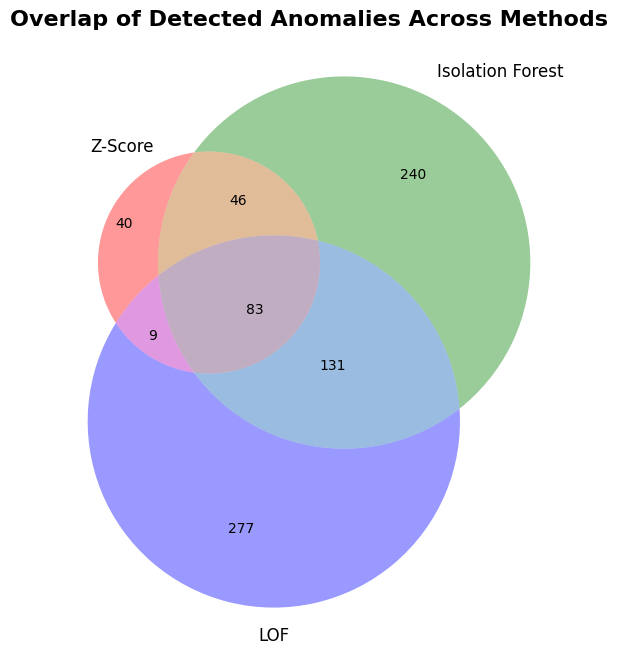

In [11]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import numpy as np

z_idx = set(np.where(outliers_zscore)[0])
iso_idx = set(np.where(outliers_iso)[0])
lof_idx = set(np.where(outliers_lof)[0])

print("--- Anomaly Overlap Summary ---")
print(f"Total anomalies by Z-Score: {len(z_idx)}")
print(f"Total anomalies by Isolation Forest: {len(iso_idx)}")
print(f"Total anomalies by LOF: {len(lof_idx)}")

shared_by_all = z_idx.intersection(iso_idx).intersection(lof_idx)
print(f"\nExtremely Anomalous States (Shared by ALL methods): {len(shared_by_all)}")

plt.figure(figsize=(10, 8))
venn = venn3([z_idx, iso_idx, lof_idx], ('Z-Score', 'Isolation Forest', 'LOF'))

plt.title('Overlap of Detected Anomalies Across Methods', fontsize=16, fontweight='bold')
plt.show()

**Comparing all anomaly detection methods based on the generated Venn Diagram:**
* **Which anomalies are shared between methods:** According to the Venn diagram, exactly 83 anomalies are shared across all three methods. These represent the absolute most extreme, undeniable machine failures in the dataset—points that are globally extreme, structurally isolated, and locally sparse. Additionally, Isolation Forest (IF) and LOF share a significant chunk of 131 anomalies that the Z-Score completely missed, highlighting that density and isolation approaches detect complex, multi-dimensional failures that a simple statistical threshold cannot.
* **Which anomalies are method-specific:** LOF has the highest number of unique detections (277), reflecting its ability to find highly localized, contextual anomalies hidden deep within the normal data ranges. Isolation Forest uniquely identified 240 anomalies, representing structural outliers on the global fringes of the 8-dimensional space. Z-Score is the most conservative, uniquely flagging only 40 anomalies, proving its feature-wise limitations.
* **Sensitivity to scaling:** Z-Score and LOF are inherently distance-based mathematically, meaning they are completely dependent on Standardization (scaling). Without scaling, features with large magnitudes (like Rotational Speed) would entirely dominate the algorithms. Isolation Forest, however, relies on decision-tree splits, making it inherently scale-invariant.
* **Sensitivity to dimensionality:** Z-Score degrades rapidly in high dimensions due to the Multiple Testing Problem (the probability of random false positives increases with each added sensor). LOF degrades because spatial distances homogenize in high dimensions (the Curse of Dimensionality). IF excels in high dimensions because it randomly selects single features for splitting, effectively ignoring irrelevant dimensions.
* **Runtime considerations:** Z-Score is computationally the fastest ($O(N)$). Isolation Forest is highly scalable for massive datasets ($O(N \log N)$). LOF is the most computationally expensive and slowest ($O(N^2)$) because it requires calculating pairwise distances between all points in the dataset.
* **Robustness to noise:** Z-Score is highly vulnerable to noise, as extreme values pull the global mean and expand the standard deviation. LOF is moderately robust but can sometimes mistake sparse noise patches for local anomalies. IF isolates random noise efficiently with short path lengths, making it the most robust algorithm among the three.
* **Interpretability:** Z-Score is perfectly interpretable (we know exactly how many standard deviations a point is from the mean for a specific sensor). IF and LOF act more like "black boxes"—they provide an overall anomaly score, but do not directly explain which specific feature caused the anomaly.
* **False positives vs false negatives:** In industrial predictive maintenance, a false negative (missing a machine breakdown) is catastrophically expensive, while a false positive (inspecting a healthy machine) is a minor inconvenience. By explicitly setting a 5% contamination rate, IF and LOF (500 points each) intentionally accept a higher False Positive rate to aggressively minimize False Negatives. The Z-Score, finding only 178 anomalies, is far too conservative and likely suffers from a dangerous False Negative rate, missing actual impending machine failures.





















7. **Critical Analysis and Reflection**

**Discussion of Theoretical Concepts in Anomaly Detection:**
* **Why anomaly detection is fundamentally difficult:** Anomaly detection is intrinsically challenging due to the extreme class imbalance and the lack of labeled data in real-world scenarios. By definition, anomalies are rare events. Because they are so infrequent, we cannot train standard supervised learning classifiers (like Neural Networks or Random Forests) to recognize them. Furthermore, anomalies are highly heterogeneous—while normal operation follows a predictable pattern, a machine can fail in an infinite number of unpredictable ways. The model must define a complex boundary for "normalcy" and assume anything outside it is an anomaly, which often leads to high false-positive rates.
* **Curse of dimensionality:** The "Curse of Dimensionality" refers to the exponential explosion in volume associated with adding extra dimensions to a mathematical space. If we consider a space discretized into grids, adding a dimension increases the number of grid cells exponentially ($10^1$ for 1D, $10^2$ for 2D, $10^8$ for 8D). As the volume grows exponentially, the available data points become incredibly sparse. To maintain the same level of statistical significance and density that we have in 2D, the amount of data required in 8D or 100D must grow exponentially, which is impossible to collect in reality.
* **Why distance becomes problematic in high dimensions:** This is a direct mathematical consequence of the curse of dimensionality. Algorithms like K-Means, LOF, and DBSCAN rely heavily on Euclidean distance. Let $D$ be the number of dimensions. As $D \to \infty$, the distance to the nearest neighbor ($d_{min}$) and the distance to the farthest neighbor ($d_{max}$) converge. Mathematically, it has been proven that:$$\lim_{D \to \infty} \frac{d_{max} - d_{min}}{d_{min}} = 0$$This means the relative contrast between distances vanishes. Every point appears to be almost completely equidistant from every other point. When nearest neighbors are no longer meaningfully "near," distance-based clustering algorithms collapse and become unable to distinguish distinct dense clusters from sparse anomalies.
* **Difference between noise and anomaly:** While both represent deviations from the mean, they are fundamentally different. Noise is expected, stochastic variance around a true signal (e.g., normal mechanical vibrations or minor electrical sensor interference). It is an endogenous part of the normal data-generating process. An anomaly, however, is generated by an entirely different, exogenous underlying mechanism (e.g., a physical gear breaking or a sudden power surge). Filtering out noise is a preprocessing step; detecting an anomaly is the end goal of predictive maintenance.
* **The danger of assuming Gaussian distributions:** Classical statistical methods (like the Z-score) rigidly assume data follows a Gaussian (Normal) distribution, bounded by the empirical rule (68-95-99.7). Under a perfect Gaussian curve, an event that is $5\sigma$ or $6\sigma$ away from the mean is deemed mathematically impossible (a probability of roughly 1 in a billion). However, real-world physical and industrial systems often exhibit "heavy-tailed" or power-law distributions. In heavy-tailed distributions, extreme outliers (Black Swan events) happen exponentially more often than a Gaussian curve predicts. Forcing a Gaussian assumption onto non-Gaussian industrial data leads to massive false-negative rates, where the model completely ignores catastrophic outliers.
* **Why visualization may be misleading after dimensionality reduction:** Techniques like Principal Component Analysis (PCA) project high-dimensional data (e.g., 8 features) down to 2 or 3 dimensions so human eyes can comprehend it. However, PCA's objective is strictly to maximize global variance, not to preserve local anomaly boundaries. A point might be a severe, isolated anomaly lying far away on the 8th Principal Component ($PC_8$). When we flatten the data down to only $PC_1$ and $PC_2$ for a scatter plot, that specific orthogonal vector is collapsed. Consequently, the point is visually projected directly into the center of the "normal" data cloud. Relying purely on 2D visualizations can mask severe multidimensional anomalies.














8. **Final Visualization Dashboard**

Building Final Visualization Dashboard...



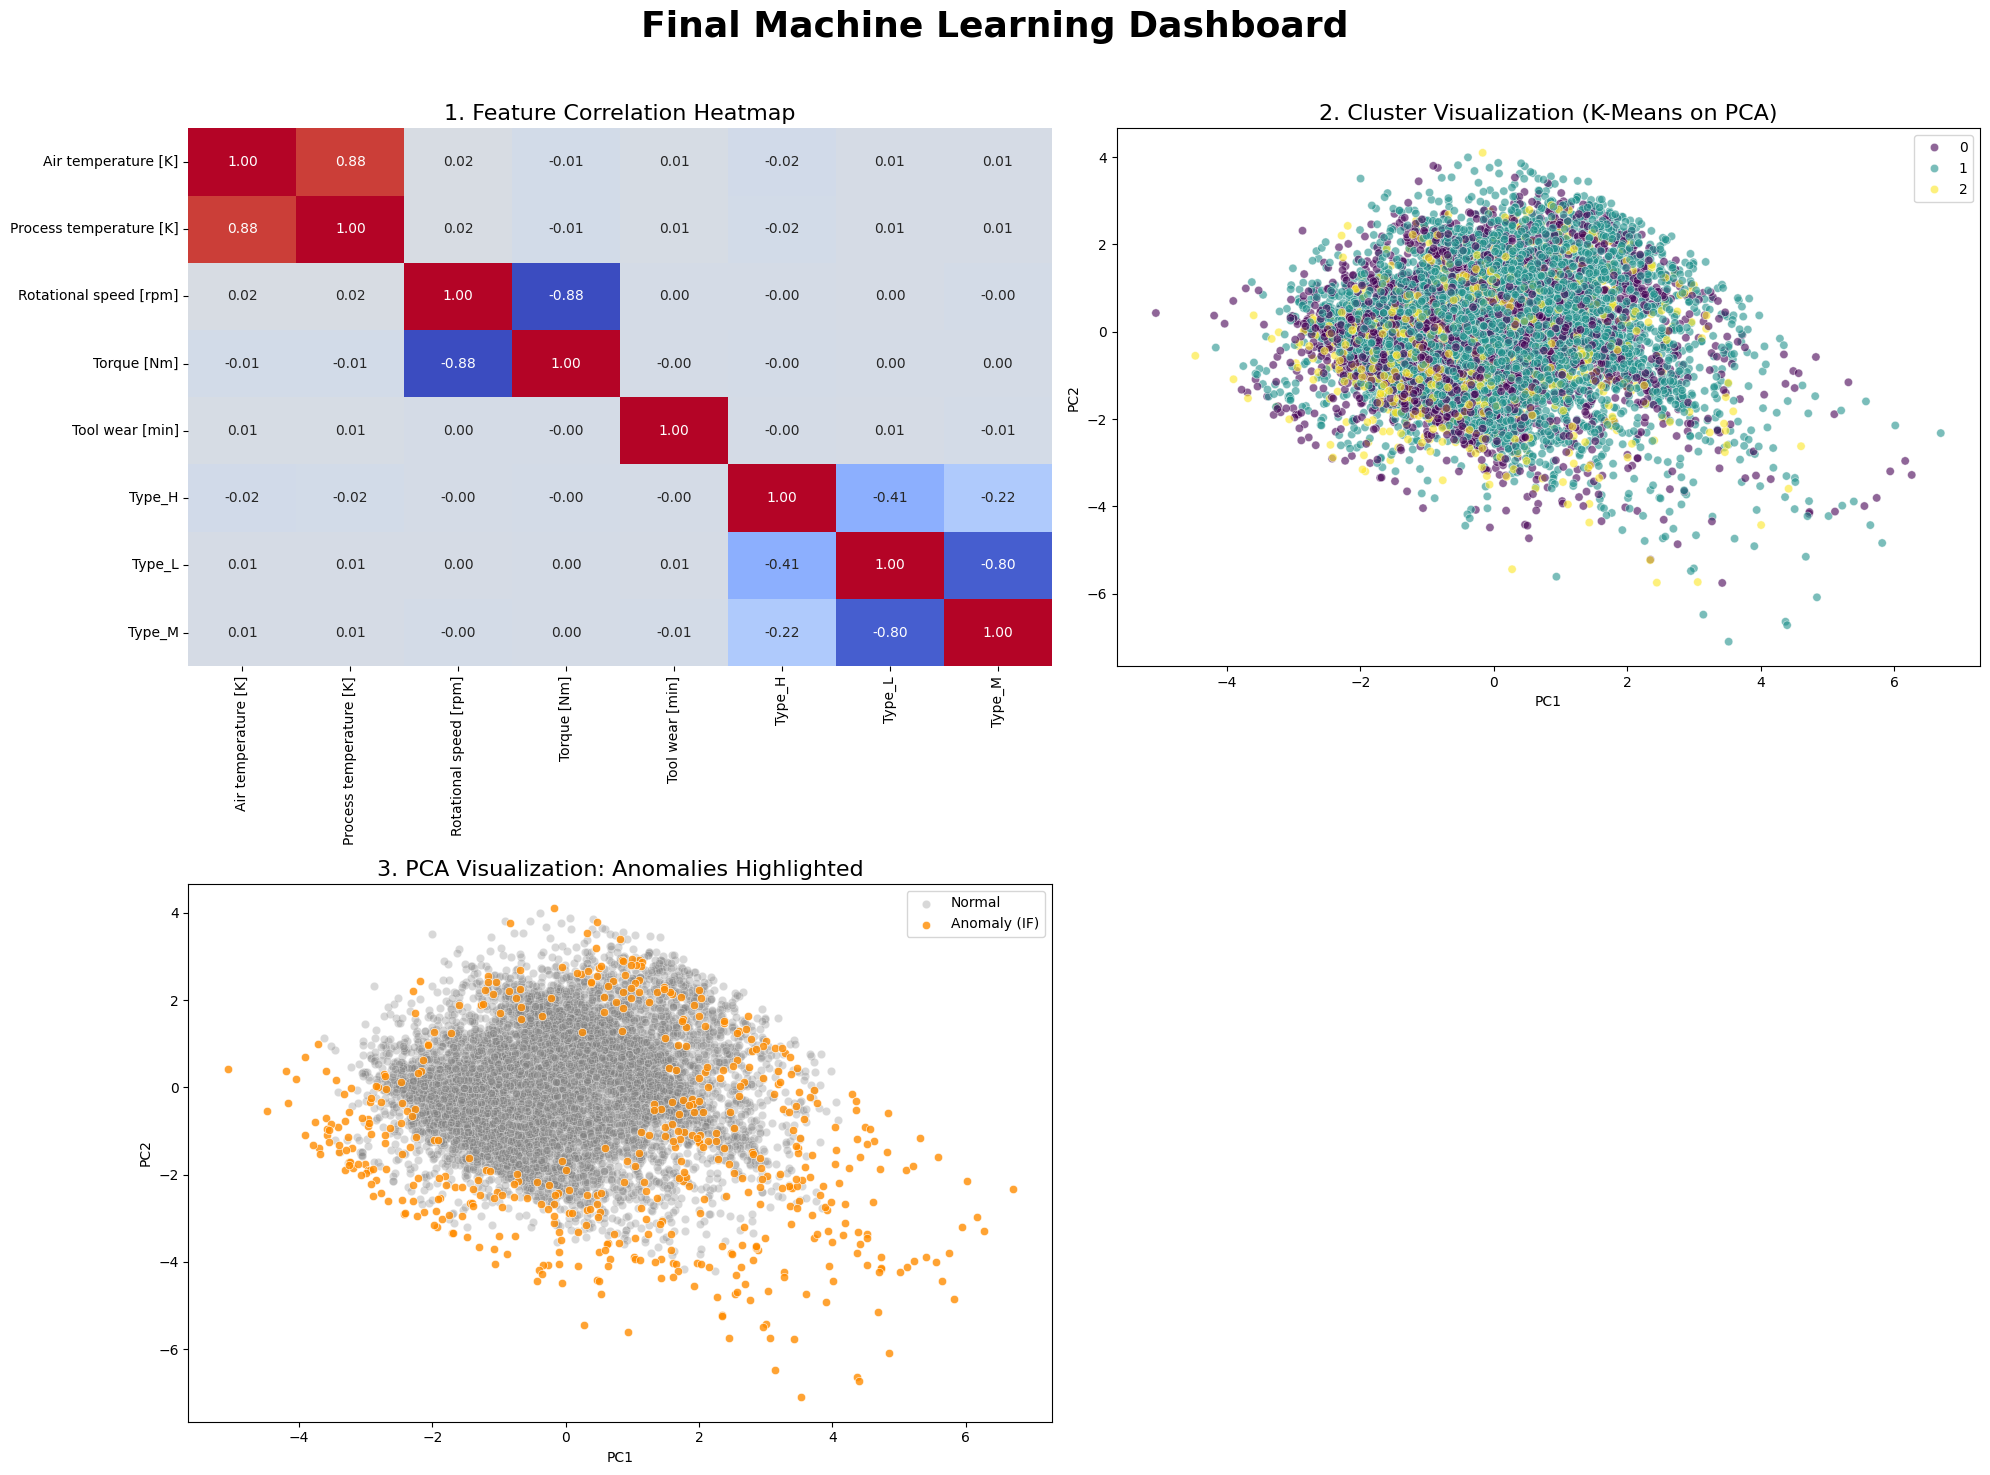


Generating Pairplot (Core Features)...


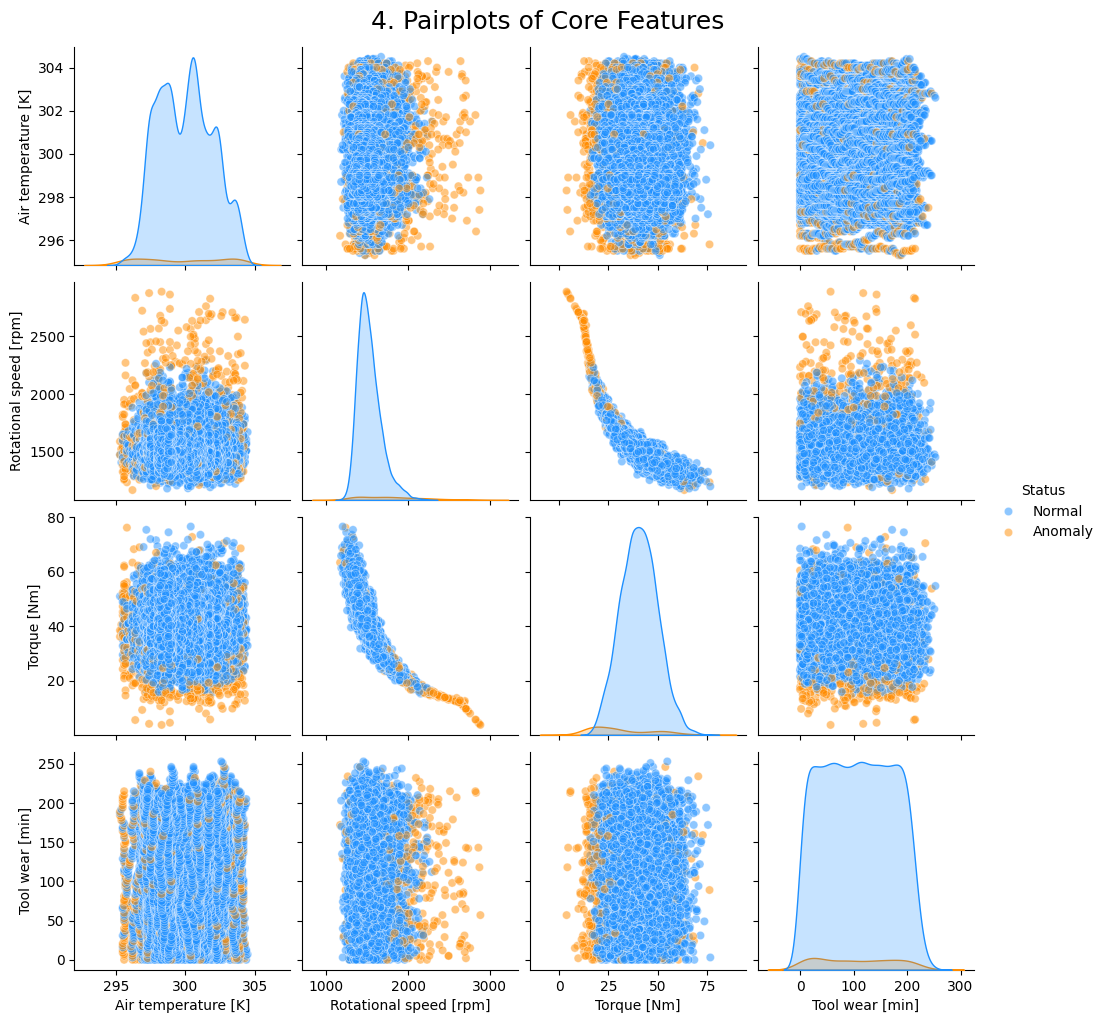


Generating Interactive 3D Anomaly Exploration (Plotly)...


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.cluster import KMeans

print("Building Final Visualization Dashboard...\n")

fig = plt.figure(figsize=(20, 15))
fig.suptitle('Final Machine Learning Dashboard', fontsize=26, fontweight='bold', y=0.98)

ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax1, cbar=False)
ax1.set_title('1. Feature Correlation Heatmap', fontsize=16)

ax2 = plt.subplot(2, 2, 2)

kmeans_dash = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(df_scaled)
sns.scatterplot(x=pca_features[:, 0], y=pca_features[:, 1], hue=kmeans_dash, palette='viridis', alpha=0.6, ax=ax2)
ax2.set_title('2. Cluster Visualization (K-Means on PCA)', fontsize=16)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

ax3 = plt.subplot(2, 2, 3)
sns.scatterplot(x=pca_features[~outliers_iso, 0], y=pca_features[~outliers_iso, 1], alpha=0.3, color='gray', label='Normal', ax=ax3)
sns.scatterplot(x=pca_features[outliers_iso, 0], y=pca_features[outliers_iso, 1], alpha=0.8, color='darkorange', label='Anomaly (IF)', ax=ax3)
ax3.set_title('3. PCA Visualization: Anomalies Highlighted', fontsize=16)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.legend()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nGenerating Pairplot (Core Features)...")

core_features = ['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_pair = df[core_features].copy()
df_pair['Status'] = np.where(outliers_iso, 'Anomaly', 'Normal')
sns.pairplot(df_pair, hue='Status', palette={'Normal': 'dodgerblue', 'Anomaly': 'darkorange'},
             plot_kws={'alpha': 0.5}, diag_kind='kde')
plt.suptitle('4. Pairplots of Core Features', y=1.02, fontsize=18)
plt.show()

print("\nGenerating Interactive 3D Anomaly Exploration (Plotly)...")
df_interact = df.copy()
df_interact['PC1'] = pca_features[:, 0]
df_interact['PC2'] = pca_features[:, 1]
df_interact['PC3'] = pca_features[:, 2]
df_interact['Anomaly_Status'] = np.where(outliers_iso, 'Anomaly', 'Normal')

fig_interact = px.scatter_3d(
    df_interact, x='PC1', y='PC2', z='PC3',
    color='Anomaly_Status',
    color_discrete_map={'Normal': 'lightblue', 'Anomaly': 'red'},
    hover_data=['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
    title='5. Interactive Anomaly Exploration (Rotate & Hover for Sensor Data)',
    opacity=0.7
)
fig_interact.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_interact.show()